In [15]:
import pandas as pd
import matplotlib.pyplot as plt
file_path = 'bestsellers with categories.csv'
df = pd.read_csv(file_path)
print(df.head())
print(df.shape)
# Про скільки книг зберігає дані датасет?
# Відповідь: 550

                                                Name  \
0                      10-Day Green Smoothie Cleanse   
1                                  11/22/63: A Novel   
2            12 Rules for Life: An Antidote to Chaos   
3                             1984 (Signet Classics)   
4  5,000 Awesome Facts (About Everything!) (Natio...   

                     Author  User Rating  Reviews  Price  Year        Genre  
0                  JJ Smith          4.7    17350      8  2016  Non Fiction  
1              Stephen King          4.6     2052     22  2011      Fiction  
2        Jordan B. Peterson          4.7    18979     15  2018  Non Fiction  
3             George Orwell          4.7    21424      6  2017      Fiction  
4  National Geographic Kids          4.8     7665     12  2019  Non Fiction  
(550, 7)


In [16]:
df.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']
print(df.head())

                                                name  \
0                      10-Day Green Smoothie Cleanse   
1                                  11/22/63: A Novel   
2            12 Rules for Life: An Antidote to Chaos   
3                             1984 (Signet Classics)   
4  5,000 Awesome Facts (About Everything!) (Natio...   

                     author  user_rating  reviews  price  year        genre  
0                  JJ Smith          4.7    17350      8  2016  Non Fiction  
1              Stephen King          4.6     2052     22  2011      Fiction  
2        Jordan B. Peterson          4.7    18979     15  2018  Non Fiction  
3             George Orwell          4.7    21424      6  2017      Fiction  
4  National Geographic Kids          4.8     7665     12  2019  Non Fiction  


In [17]:
missinig_count = df.isna().sum()
print(missinig_count)
# Чи є в якихось змінних пропуски?
# Відповідь: Ні

name           0
author         0
user_rating    0
reviews        0
price          0
year           0
genre          0
dtype: int64


In [18]:
print(df['genre'].unique())
# Які є унікальні жанри?
# Відповідь: 'Non Fiction' 'Fiction'

['Non Fiction' 'Fiction']


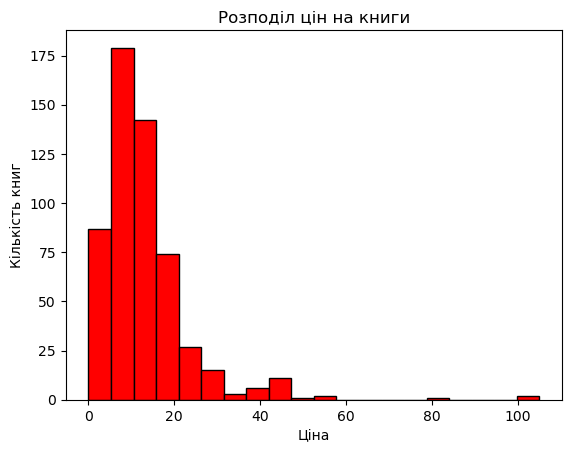

In [33]:
df['price'].plot(kind='hist', bins=20, color='red', edgecolor='black')
plt.title("Розподіл цін на книги")
plt.xlabel("Ціна")
plt.ylabel("Кількість книг")
plt.show()

In [38]:
max_price = df['price'].max()
min_price = df['price'].min()
avg_price = df['price'].mean()
median_price = df['price'].median()
print(max_price)
print(min_price)
print(avg_price)
print(median_price)
# Максимальна ціна? Відповідь:105
# Мінімальна ціна? Відповідь:0
# Cередня ціна? Відповідь: 13.1
# Медіанна ціна? Відповідь: 11.0

105
0
13.1
11.0


In [40]:
max_rating = df['user_rating'].max()
print(max_rating)
# Який рейтинг у датасеті найвищий? Відповідь:4.9

4.9


In [44]:
count_book_with_max_rating = df[df['user_rating'] == max_rating].shape[0]
print(count_book_with_max_rating)
# Скільки книг мають такий рейтинг? Відповідь:52

52


In [48]:
book_with_max_reviews = df[df['reviews'] == df['reviews'].max()]['name'].tolist()
print(book_with_max_reviews)
# Яка книга має найбільше відгуків? Відповідь: 'Where the Crawdads Sing'

['Where the Crawdads Sing']


In [58]:
book_2015y = df[df['year'] == 2015]
book_2015y = book_2015y.sort_values('user_rating',ascending=False)
print(book_2015y[book_2015y['price'] == book_2015y['price'].max()]['name'].tolist())
# З тих книг, що потрапили до Топ-50 у 2015 році, яка книга найдорожча (можна використати проміжний датафрейм)? Відповідь: 'Publication Manual of the American Psychological Association, 6th Edition'

['Publication Manual of the American Psychological Association, 6th Edition']


In [59]:
fiction_2010 = df[(df['genre'] == 'Fiction') & (df['year'] == 2010)]
print(fiction_2010.shape[0])
# Скільки книг жанру Fiction потрапили до Топ-50 у 2010 році (використовуйте &)? Відповідь: 20

20


In [60]:
book_with_4_9_in_2010_2011 = df[(df['user_rating'] == 4.9) & ((df['year'] == 2010)|(df['year'] == 2011))]
print(book_with_4_9_in_2010_2011.shape[0])
# Скільки книг з рейтингом 4.9 потрапило до рейтингу у 2010 та 2011 роках (використовуйте | або функцію isin)? Відповідь:1

1


In [64]:
book_by_2015y_less_8dol = df[(df['year'] == 2015) & (df['price'] < 8)]
sorted_by_price = book_by_2015y_less_8dol.sort_values('price')
last_book = sorted_by_price.iloc[-1]
print(last_book['name'])
# Яка книга остання у відсортованому списку? Відповідь:Old School (Diary of a Wimpy Kid #10)

Old School (Diary of a Wimpy Kid #10)


In [68]:
df.groupby('genre').agg({'price':['min','max']})
# Максимальна ціна для жанру Fiction: Відповідь:82
# Мінімальна ціна для жанру Fiction: Відповідь:0
# Максимальна ціна для жанру Non Fiction: Відповідь:105
# Мінімальна ціна для жанру Non Fiction: Відповідь:0

price     
              min  max
genre                 
Fiction         0   82
Non Fiction     0  105

In [86]:
count_book_for_author = df.groupby('author').agg({'name':'count'})
count_book_for_author.rename(columns={'name': 'book_count'}, inplace=True)
print(count_book_for_author.shape)
print(count_book_for_author[count_book_for_author['book_count'] == count_book_for_author['book_count'].max()])
# Якої розмірності вийшла таблиця? Відповідь:(248, 1)
# Який автор має найбільше книг? Відповідь: Jeff Kinney
# Скільки книг цього автора? Відповідь:12

(248, 1)
             book_count
author                 
Jeff Kinney          12


In [87]:
avg_rating_for_author = df.groupby('author').agg({'user_rating':'mean'})
print(avg_rating_for_author[avg_rating_for_author['user_rating'] == avg_rating_for_author['user_rating'].min()])
# У якого автора середній рейтинг мінімальний? Відповідь: Donna Tartt
# Який у цього автора середній рейтинг? Відповідь: 3.9

             user_rating
author                  
Donna Tartt          3.9


In [88]:
info_for_authors = pd.concat([count_book_for_author,avg_rating_for_author],axis =1)

print(info_for_authors.sort_values(['book_count','user_rating']))
# Який автор перший у списку? Відповідь:Muriel Barbery 

                                    book_count  user_rating
author                                                     
Muriel Barbery                               1     4.000000
Chris Cleave                                 1     4.100000
Ian K. Smith M.D.                            1     4.100000
Pierre Dukan                                 1     4.100000
Elizabeth Strout                             1     4.200000
...                                        ...          ...
American Psychological Association          10     4.500000
Suzanne Collins                             11     4.663636
Gary Chapman                                11     4.736364
Rick Riordan                                11     4.772727
Jeff Kinney                                 12     4.800000

[248 rows x 2 columns]


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7932\3164507085.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="year", palette="coolwarm")


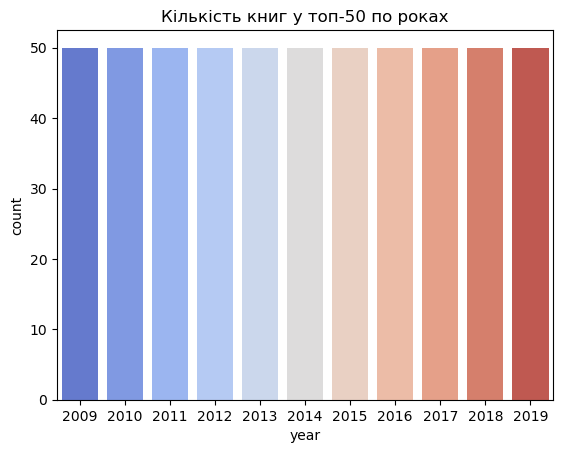

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="year", palette="coolwarm")
plt.title("Кількість книг у топ-50 по роках")
plt.show()

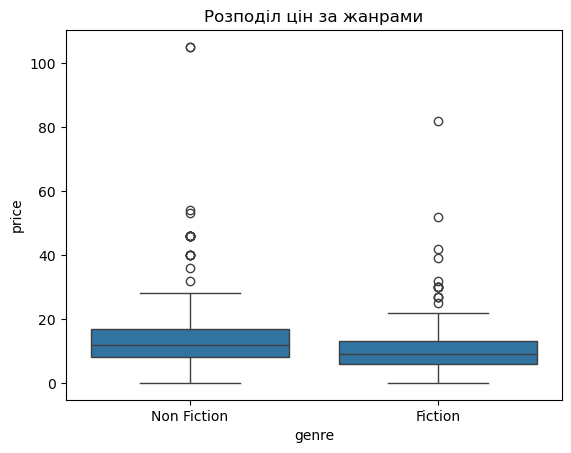

In [93]:
sns.boxplot(data=df, x="genre", y="price")
plt.title("Розподіл цін за жанрами")
plt.show()

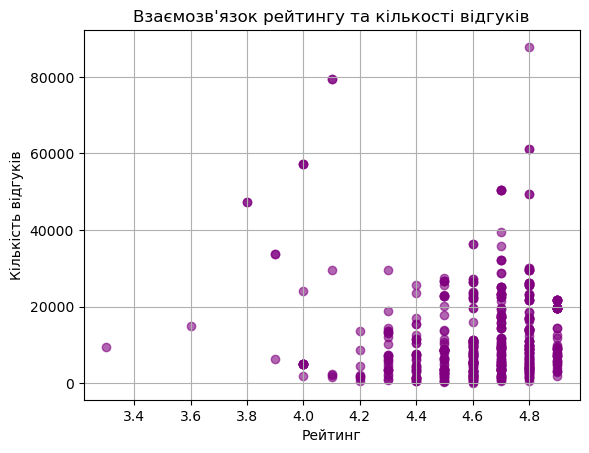

In [95]:
plt.scatter(df["user_rating"], df["reviews"], alpha=0.6, color="purple")
plt.xlabel("Рейтинг")
plt.ylabel("Кількість відгуків")
plt.title("Взаємозв'язок рейтингу та кількості відгуків")
plt.grid(True)
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7932\2986437010.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_authors.index, y=top_authors.values, palette='viridis')


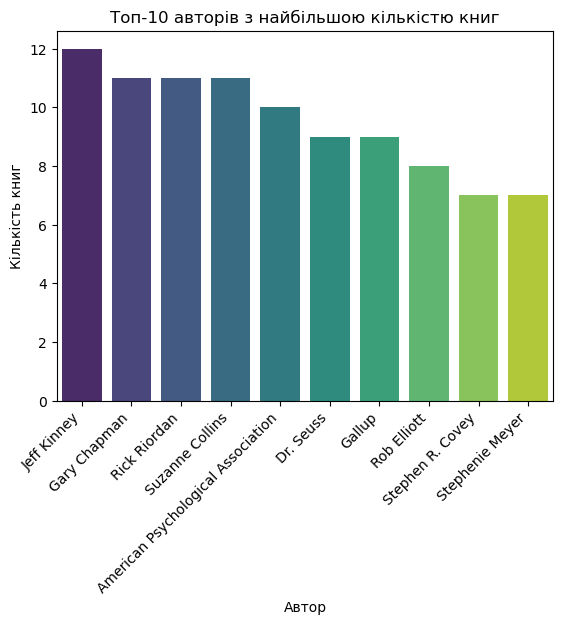

In [97]:
top_authors = df['author'].value_counts().head(10)

sns.barplot(x=top_authors.index, y=top_authors.values, palette='viridis')

plt.title("Топ-10 авторів з найбільшою кількістю книг")
plt.xlabel("Автор")
plt.ylabel("Кількість книг")
plt.xticks(rotation=45, ha="right")
plt.show()